<div align="center">

# Лабораторна робота №2 ІАД
**Тема:** NumPy, pandas і Matplotlib для підготовки, аналізу та візуалізації даних

**Мета:** Ознайомитися з основами роботи з бібліотеками NumPy, Pandas та Matplotlib для аналізу даних, проведення базових операцій з даними та візуалізації результатів.

**Студентка:** Сабадаш Анастасія  
**Група:** МІТ-31  
**Варіант:** 2

</div>

### Завдання 1. Робота з бібліотекою NumPy

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

seed = 2
a = 2.4
b = 35.0
sigma = 5.0

rng = np.random.default_rng(seed)

x = np.linspace(0, 20, 100)

y_hat = a * x + b
noise = rng.normal(loc=0, scale=sigma, size=x.size)
y_observed = y_hat + noise

matrix = np.column_stack((x, y_hat, noise, y_observed))
print("shape:", matrix.shape)
print("ndim:", matrix.ndim)
print("size:", matrix.size)
print("dtype:", matrix.dtype)

print("Елемент за індексом 0:", matrix[0])
print("Зріз перших 3 рядків:\n", matrix[:3])

filtered = matrix[matrix[:, 3] > 50]
print("Рядків, де y_observed > 50:", filtered.shape[0])

sub_copy = matrix[:5].copy()
sub_copy[0, 3] = 999.0

matrix_reduced = np.delete(matrix, 0, axis=0)

y_obs = matrix[:, 3]
print("Мінімум y_observed:", y_obs.min())
print("Максимум y_observed:", y_obs.max())
print("Середнє y_observed:", y_obs.mean())
print("Стандартне відхилення y_observed:", y_obs.std())
print("Агрегація за axis=0 (середнє по стовпцях):\n", matrix.mean(axis=0))

shape: (100, 4)
ndim: 2
size: 400
dtype: float64
Елемент за індексом 0: [ 0.         35.          0.94526691 35.94526691]
Зріз перших 3 рядків:
 [[ 0.         35.          0.94526691 35.94526691]
 [ 0.2020202  35.48484848 -2.61374221 32.87110628]
 [ 0.4040404  35.96969697 -2.06531772 33.90437925]]
Рядків, де y_observed > 50: 70
Мінімум y_observed: 24.247208541346176
Максимум y_observed: 85.77908366221754
Середнє y_observed: 58.957903002013765
Стандартне відхилення y_observed: 14.471899798410945
Агрегація за axis=0 (середнє по стовпцях):
 [ 1.0000000e+01  5.9000000e+01 -4.2096998e-02  5.8957903e+01]


Висновок: Сформовано масив даних та перевірено його структуру. Отриманий `shape` (100, 4) означає, що масив містить 100 рядків (відповідно до кількості значень x) та 4 стовпці (x, y_hat, noise, y_observed). Отриманий `dtype` (float64) вказує на те, що всі елементи масиву є числами з плаваючою комою подвійної точності (64 біти), що є стандартним форматом для математичних обчислень у NumPy.

### Завдання 2. Робота з бібліотекою Pandas

In [2]:
df = pd.DataFrame({
    "x": x,
    "y_true": y_hat,
    "noise": noise,
    "y_observed": y_observed,
})
df["group"] = pd.qcut(df["x"], q=3, labels=["low", "medium", "high"])

print(df.head())
print(df.shape)
print(df.dtypes)
df.info()
print(df.describe())

df_copy = df.copy()
df_copy.loc[1:3, "y_observed"] = np.nan
df_copy = pd.concat([df_copy, df_copy.iloc[[0]]], ignore_index=True)

print(df_copy.isna().sum())
print("Дублікати:", df_copy.duplicated().sum())

df_clean = df_copy.drop_duplicates().copy()
median_val = df_clean["y_observed"].median()
df_clean["y_observed"] = df_clean["y_observed"].fillna(median_val)

print(df_clean.isna().sum())
print("Медіана для заповнення:", median_val)

print(df_clean.loc[df_clean["y_observed"] > 50, ["x", "y_observed", "group"]])
print(df_clean.iloc[0:5, 0:3])
print(df_clean[df_clean["y_observed"] > 50].head())
print(df_clean.sort_values(by="y_observed", ascending=False).head())

group_stats = df_clean.groupby("group").agg(
    mean_y_observed=("y_observed", "mean"),
    std_y_observed=("y_observed", "std"),
    count_rows=("y_observed", "size")
)
print(group_stats)

          x     y_true      noise  y_observed group
0  0.000000  35.000000   0.945267   35.945267   low
1  0.202020  35.484848  -2.613742   32.871106   low
2  0.404040  35.969697  -2.065318   33.904379   low
3  0.606061  36.454545 -12.207337   24.247209   low
4  0.808081  36.939394   8.998537   45.937931   low
(100, 5)
x              float64
y_true         float64
noise          float64
y_observed     float64
group         category
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   x           100 non-null    float64 
 1   y_true      100 non-null    float64 
 2   noise       100 non-null    float64 
 3   y_observed  100 non-null    float64 
 4   group       100 non-null    category
dtypes: category(1), float64(4)
memory usage: 3.5 KB
                x      y_true       noise  y_observed
count  100.000000  100.000000  100.000000  100.000000
mea

Висновок: Створено та проаналізовано DataFrame розмірністю 100 рядків і 5 стовпців (`x`, `y_true`, `noise`, `y_observed`, `group`). Проведено первинний аналіз за допомогою методів `head`, `shape`, `dtypes`, `info` та `describe`. Штучно внесено та успішно оброблено пропуски й дублікати: дублі видалено через `drop_duplicates()`, а пропуски заповнено медіаною, яка є стійкою до викидів. Продемонстровано вибірку даних через `loc` та `iloc`, булеву фільтрацію й сортування. За допомогою групування (`groupby`) та агрегації (`size`) обчислено середнє значення, стандартне відхилення та кількість рядків для кожної категорії `group`.

### Завдання 3. Візуалізація даних та обчислення метрик похибки

MAE (Середня абсолютна похибка): 4.3877
MSE (Середня квадратична похибка): 40.1030


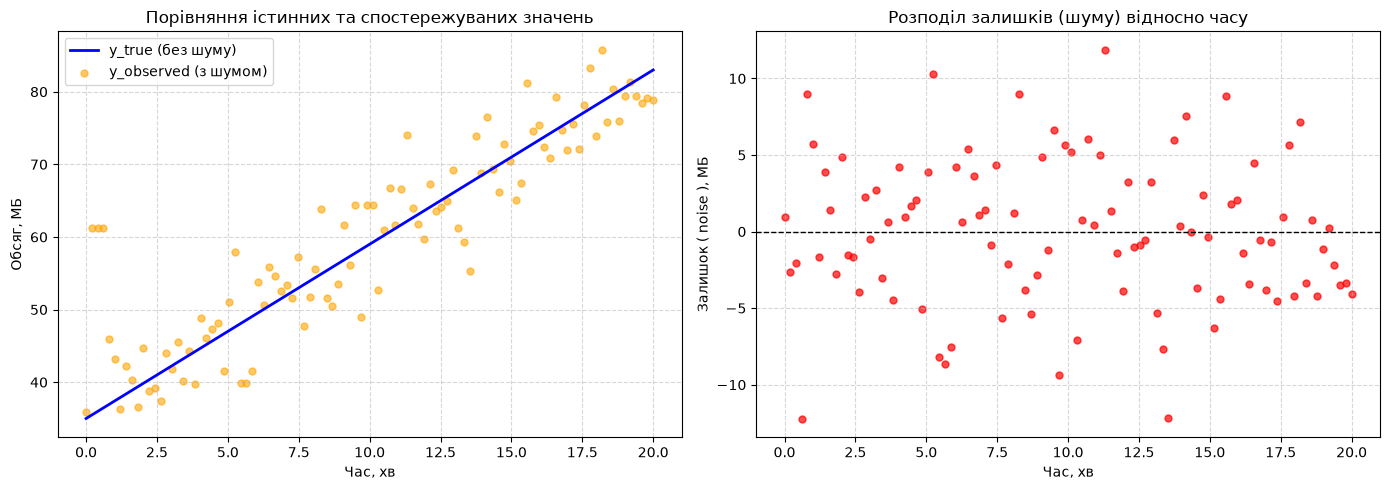

Успішно збережено: Lab2_results.csv, Lab2_results.parquet, Lab2_summary.csv та графік Lab2_plot.png


In [3]:
mae = np.mean(np.abs(df_clean["y_observed"] - df_clean["y_true"]))
mse = np.mean((df_clean["y_observed"] - df_clean["y_true"]) ** 2)

print(f"MAE (Середня абсолютна похибка): {mae:.4f}")
print(f"MSE (Середня квадратична похибка): {mse:.4f}")

df_clean["absolute_error"] = np.abs(df_clean["y_observed"] - df_clean["y_true"])
df_clean["squared_error"] = (df_clean["y_observed"] - df_clean["y_true"]) ** 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(df_clean["x"], df_clean["y_true"], label="y_true (без шуму)", color="blue", linewidth=2)
ax1.scatter(df_clean["x"], df_clean["y_observed"], label="y_observed (з шумом)", color="orange", alpha=0.6, s=25)
ax1.set_title("Порівняння істинних та спостережуваних значень")
ax1.set(xlabel="Час, хв", ylabel="Обсяг, МБ")
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.5)

ax2.scatter(df_clean["x"], df_clean["noise"], color="red", alpha=0.7, s=25)
ax2.set_title("Розподіл залишків (шуму) відносно часу")
ax2.set(xlabel="Час, хв", ylabel="Залишок ( noise ), МБ")
ax2.axhline(0, color="black", linestyle="--", linewidth=1)
ax2.grid(True, linestyle="--", alpha=0.5)

plt.tight_layout()

plt.savefig("Lab2_plot.png", dpi=300)
plt.show()

df_export = df_clean.copy()
for col in df_export.select_dtypes(include=["category", "object"]).columns:
    df_export[col] = df_export[col].astype(str)

df_export.to_csv("Lab2_results.csv", index=False)
df_export.to_parquet("Lab2_results.parquet", index=False)
group_stats.to_csv("Lab2_summary.csv")

print("Успішно збережено: Lab2_results.csv, Lab2_results.parquet, Lab2_summary.csv та графік Lab2_plot.png")

Висновок: Обчислено метрики похибки MAE та MSE для оцінки відхилень спостережуваних значень мережевого трафіку від істинних. У таблицю додано стовпці `absolute_error` та `squared_error`. Засобами Matplotlib побудовано парні графіки з українськими підписами та одиницями вимірювання (час у хвилинах, обсяг у МБ), що ілюструють динаміку показників і розподіл залишків. Рисунок збережено у високій якості (dpi=300), а результати успішно експортовано у формати CSV та Parquet разом зі зведеною статистикою.